# RFM Analysis on E-commerce dataset

<div style="background-color: #f0f7ff; border-left: 5px solid #5C9AFF; padding: 15px; border-radius: 5px; font-family: 'Roboto', sans-serif;">
    <p style="margin: 0; color: #002047;"><strong>Dataset:</strong> E-commerce dataset</p>
    <p style="margin: 5px 0; color: #002047;"><strong>Source:</strong> <a href="https://www.kaggle.com/datasets/carrie1/ecommerce-data" style="color: #5C9AFF;">Kaggle</a></p>
    <p style="margin: 0; color: #002047;"><strong>Author:</strong> Fishchenko Tamara</p>
</div>


### Styling headers and markdown cells
To improve the document's visual structure and readability, I chose Roboto as my main font, as well as a monochromatic blue gradient to headers.

In [13]:
%%html
<style>
@import url('https://fonts.googleapis.com');
.jp-RenderedHTMLCommon, .text_cell_render { 
    font-family: 'Roboto', sans-serif !important; 
    font-size: 15px !important;
    line-height: 1.6 !important;
}

.jp-RenderedHTMLCommon h1, .jp-RenderedHTMLCommon h2, 
.jp-RenderedHTMLCommon h3, .jp-RenderedHTMLCommon h4 {
    padding: 15px !important;
    border-radius: 8px !important;
    margin-top: 25px !important;
    margin-bottom: 10px !important;
    font-weight: 700 !important;
}

/* # Header 1 */
.jp-RenderedHTMLCommon h1 {
    background-color: #f0f7ff !important;
    border-left: 10px solid #5C9AFF !important;
    color: #002047 !important;
}

/* ## Header 2 */
.jp-RenderedHTMLCommon h2 {
    background-color: #e1ecf7 !important;
    border-left: 10px solid #528ae5 !important;
    color: #003366 !important;
}

/* ### Header 3 */
.jp-RenderedHTMLCommon h3 {
    background-color: #d6e4f2 !important;
    border-left: 10px solid #1e4f9a !important;
    color: #002047 !important;
}

/* #### Header 4 */
.jp-RenderedHTMLCommon h4 {
    background-color: #cbdcf0 !important;
    border-left: 10px solid #002047 !important;
    color: #001530 !important;
}
</style>

### Contents

### Objective
The goal of this notebook includes solving following tasks:  
- Data cleaning and validation
- Missing values handling
- Dublicates handling
- Stock code normalization
- Feature engineering
- Outlier detection
- Graphs construction
- RFM analysis preparation and realization

### Expected result

The expected result of this analysis is a cleaned dataset with consistent formats and correct data types and a new set of new engineered features that will be used for further analysis.

## Data preparation and loading

In [272]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick
from IPython.display import display, HTML
from matplotlib.ticker import FuncFormatter
import plotly.express as px

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style="whitegrid")
NICE_BLUE = "#69aeff"
DARK_BLUE = "#000d3f"

plt.rcParams['font.family'] = 'DejaVu Sans'

In [19]:
# used parquet not to lose specified data types
df_cleaned = pd.read_parquet("df_cleaned.parquet")

# products and non-products
df_products = df_cleaned.loc[~df_cleaned["IsNonProduct"]].copy()
df_non_products = df_cleaned.loc[df_cleaned["IsNonProduct"]].copy()

## RFM analysis

Palmatier et al. (2022, Chapter 7) states, "The underlying idea of RFM analysis is that customers who have (1) purchased more recently, (2) made more purchases during a given time period; and (3) spent more on those purchases are more likely to respond to a new offer." From this we can conclude that RFM (Recency, Frequency and Monetary) analysis's purpose is to identify and evaluate the value of customers based on their purchasing behaviour using three key metrics:
* __Recency (R)__: How recently a customer made a purchase. It calculates the time difference between a customer’s most recent transaction and the reference date. Customers with lower recency are considered more valuable because they have interacted with the business recently and are more likely to respond to future marketing campaigns.
* __Frequency (F)__: How often a customer makes a purchase. Customers with high frequency values are considered loyal customers because they repeatedly return to purchase products or services. Moreover, retaining such consumers is usually cheaper than acquiring new ones.
* __Monetary (M)__: How much money a customer spends. Customers with high monetary value generate more revenue and are considered high-value customers.

RFM analysis helps businesses better understand customer behaviour and allocate marketing resources more efficiently by focusing on high-value customer groups who are most likely to generate profit and engagement rather than targeting all customers equally.

According to Wei et al. (2010), RFM analysis can be used for:
1. customer segmentation
3. customer lifetime value (CLV) analysis
4. customer retention
5. response prediction
6. profitability analysis
7. personalised marketing strategies

The same paper highlights that RFM is extremely popular among businesses, including banking, telecommunications, retail and e-commerce, because it is cost-effective, fast for development and relies on already existing data while using a few variables to provide powerful insights. Therefore, it reduces the necessity of using more complex predictive models for primary statistical analysis.

In [22]:
# making dataset for RFM
rfm_df = df_products[
    (df_products["CustomerID"].notna()) &
    (df_products["Quantity"] > 0) &
    (df_products["UnitPrice"] > 0)
].copy()

### Calculating key metrics for each customer

Since the dataset is historical and has dates ranging from December 2010 to December 2011, Recency metric needs to be based within its own timeframe and not the current date. Moreover, adding 1 day ensures that even the most recent buyer gets a recency of at least 1 to prevent issues in scoring or comparisons.

In [25]:
# finding last date in dataset
baseline_date = rfm_df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [26]:
# constructing RFM dataset 
rfm = rfm_df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (baseline_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

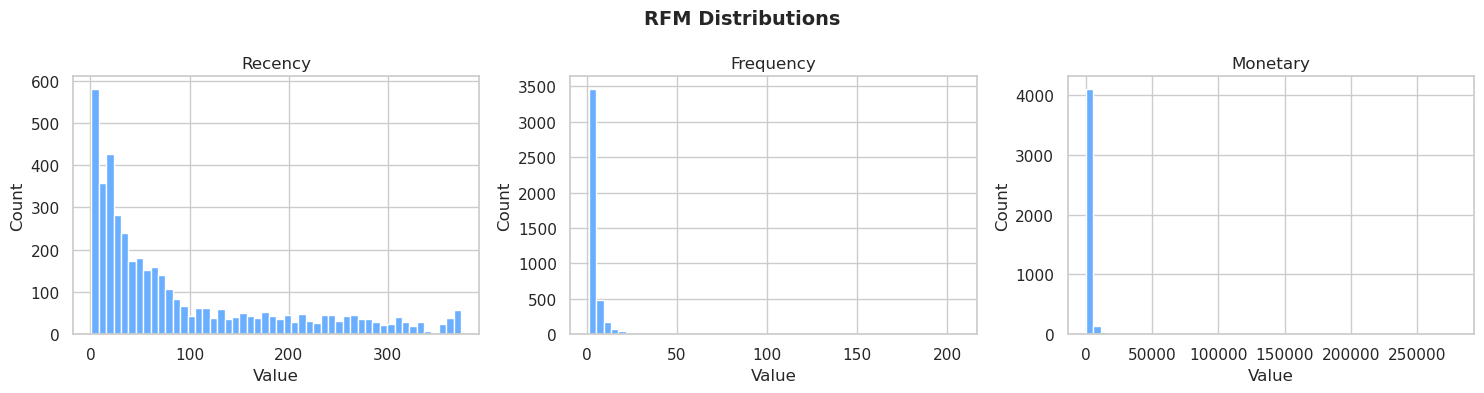

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# constructing distibutions for metrics
for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    rfm[col].hist(bins=50, ax=ax, color=NICE_BLUE)
    ax.set_title(col)
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

plt.suptitle("RFM Distributions", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()

These histograms show the distribution of RFM metrics with the following results:
1. __Recency__: right-skewed, indicating most customers bought products recently while fewer customers have been inactive for long periods.
3. __Frequency__: heavily right-skewed, where the vast majority of customers made only a few orders (about 1-5) and only a few - larger which is normal for retail datasets.
4. __Monetary__: extremely right-skewed, concentrating near £1000 (meaning many consumers contribute very little to total revenue) with outliers reaching £250,000.

In [90]:
# without log
print("Quantiles boundaries without log:")
print(pd.qcut(rfm["Monetary"], 5).value_counts().sort_index())

# with log
print("\nQuintile boundaries with log:")
print(pd.qcut(np.log1p(rfm["Monetary"]), 5).value_counts().sort_index())

Quantiles boundaries without log:
Monetary
(3.749, 246.81]          867
(246.81, 482.254]        867
(482.254, 922.056]       866
(922.056, 2029.212]      867
(2029.212, 279138.02]    867
Name: count, dtype: int64

Quintile boundaries with log:
Monetary
(1.5570000000000002, 5.513]    867
(5.513, 6.181]                 867
(6.181, 6.828]                 866
(6.828, 7.616]                 867
(7.616, 12.539]                867
Name: count, dtype: int64


As it can be observed, in the case without converting using log, the spending intervals are heavily distorted by extreme values. For instance, the last quintile spans from £2029 to £279,138, boundaries of which represent completely different client types grouped into one segment. Meanwhile, with log transformation the intervals become more balanced.

In [167]:
# calculating RFM scores
rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
# due to many clients with same number of orders, they need to be ranked for qcut to work properly
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(np.log1p(rfm["Monetary"]), 5, labels=[1,2,3,4,5])

# converting RFM scores to numeric type
rfm[["R_score", "F_score", "M_score"]] = rfm[["R_score", "F_score", "M_score"]].astype(int)

# constructing RFM score
rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment
0,12346.0,326,1,77183.60,1,1,5,115,Others
1,12347.0,2,7,4310.00,5,5,5,555,Champions
2,12348.0,75,4,1437.24,2,4,4,244,Loyal customers
3,12349.0,19,1,1457.55,4,1,4,414,Others
4,12350.0,310,1,294.40,1,1,2,112,Lost customers


### Customer segmentation

On the website [Customer Segmentation using RFM Analysis](https://blog.rsquaredacademy.com/customer-segmentation-using-rfm-analysis/), the table with possible customer segments was found. This RFM model groups customers by Recency, Frequency, and Monetary scores to identify high-value segments and key behavioural trends, which can then be used to analyse buyers' loyalty and profitability for more time- and cost-effective marketing strategies.
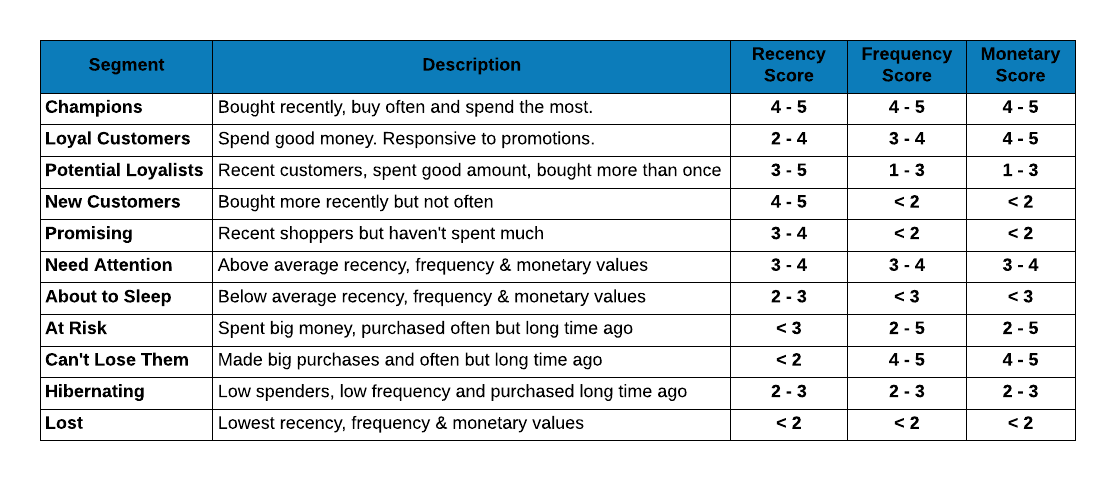
The following segments were chosen to be studied:
1. Champions
2. Loyal customers
3. New customers
4. Potential loyalists
5. Cannot lose them
6. At risk
7. Hibernating
8. Lost customers
9. Others

In [220]:
r, f, m = rfm["R_score"], rfm["F_score"], rfm["M_score"]

# conditions from the table
conditions = [
    (r >= 4) & (f >= 4) & (m >= 4), # Champions
    (r >= 2) & (f.between(3, 4)) & (m >= 4), # Loyal customers
    (r >= 4) & (f <= 2) & (m <= 2), # New customers
    (r >= 3) & (f <= 3) & (m <= 3), # Potential loyalists
    (r.between(3, 4)) & (f.between(3, 4)) & (m.between(3, 4)), # Need attention
    (r <= 2) & (f >= 4) & (m >= 4), # Cannot lose them
    (r <= 2) & (f >= 2) & (m >= 2), # At risk
    (r.between(2, 3)) & (f.between(2, 3)) & (m.between(2, 3)), # Hibernating
    (r <= 2) & (f <= 2) & (m <= 2) # Lost customers
]

# names of segments
choices = [
    "Champions", "Loyal customers", "New customers", "Potential loyalists",
    "Need attention", "Cannot lose them", "At risk", "Hibernating", "Lost customers"
]

# np.select is faster for this number of conditions compared to apply
# if client doesn't suit any group, they go to "Others"
rfm["Segment"] = np.select(conditions, choices, default="Others")

print("Total number of customers:", len(rfm["CustomerID"]))
rfm["Segment"].value_counts()

Total number of customers: 4334


Segment
Champions              956
Potential loyalists    731
Lost customers         671
At risk                633
Others                 474
Loyal customers        425
New customers          236
Need attention         139
Cannot lose them        69
Name: count, dtype: int64

In [222]:
others = rfm[rfm["Segment"] == "Others"][["R_score", "F_score", "M_score"]]

# main statistics about segment
print("Number of customers in 'Others':", len(others))
others.describe()

Number of customers in 'Others': 474


,R_score,F_score,M_score
count,474.000000,474.000000,474.000000
mean,2.957806,3.162447,3.322785
std,1.319200,1.602384,1.273916
min,1.000000,1.000000,1.000000
25%,2.000000,1.000000,3.000000
50%,3.000000,4.000000,3.000000
75%,4.000000,5.000000,4.000000
max,5.000000,5.000000,5.000000


Others represent customers with relatively average behavioural characteristics with metrics which were not defined in earlier conditions. Their means of scores confirms that they are mid-range consumers. Therefore, their segment name will be changed to be more descriptive.

In [236]:
# replacing name of segment
rfm["Segment"] = rfm["Segment"].replace({"Others": "Average customers"})

In total, there were 4334 unique customers, separated into 9 different groups: 
1. Champions (956)
2. Potential loyalists (731)
3. Lost customers (671)
4. At risk (633)
6. Average customers (474)
7. Loyal customers (425)
8. New customers (236)
9. Need attention (139)
10. Cannot lose them (69)

The largest segments were Champions and Potential loyalists (1687 together). The former represents company’s most valuable customers and should be prioritised for retention, VIP loyalty programs, unique deals and premium marketing campaigns. Meanwhile, Potential loyalists can become future champions if they are targeted with personalised promotions and loyalty programmes. Loyal customers are an important part of business as they normally generate a considerable amount of revenue. Thus, they should be controlled through loyalty programmes and personalised product recommendations.

However, At Risk and Lost customer for nearly one-third of all customers, showing a serious vulnerability. Trying to recover lost customers would be too expensive with a low return on investment (ROI), focusing on retaining at-risk consumers would be more effective. One of the suggestions is using promotional emails offering big discounts to increase re-engagement and prolong their active customer lifetime on the platform. 

Moreover, New customers contribute a very small portion of all consumers, hinting that the company stuggles to acquire new users at a sustainable or constant rate, meaning the business risks long-term stagnation once the current customer base naturally decreases. Effective onboarding strategies (e.g. discounts on first orders) need to be implemented. As for Need attention, it is necessary to send them limited-time personalised offers, which match their previous buying history to restore their interest.

Cannot Lose Them segment demands immediate intervention as they directly impact on profitability (their orders are expensive) but for some reason stopped making purchases recently. To find out why and get them back, the company should contact them  and offer special deals if they make them within some timeframe.

### Graphs

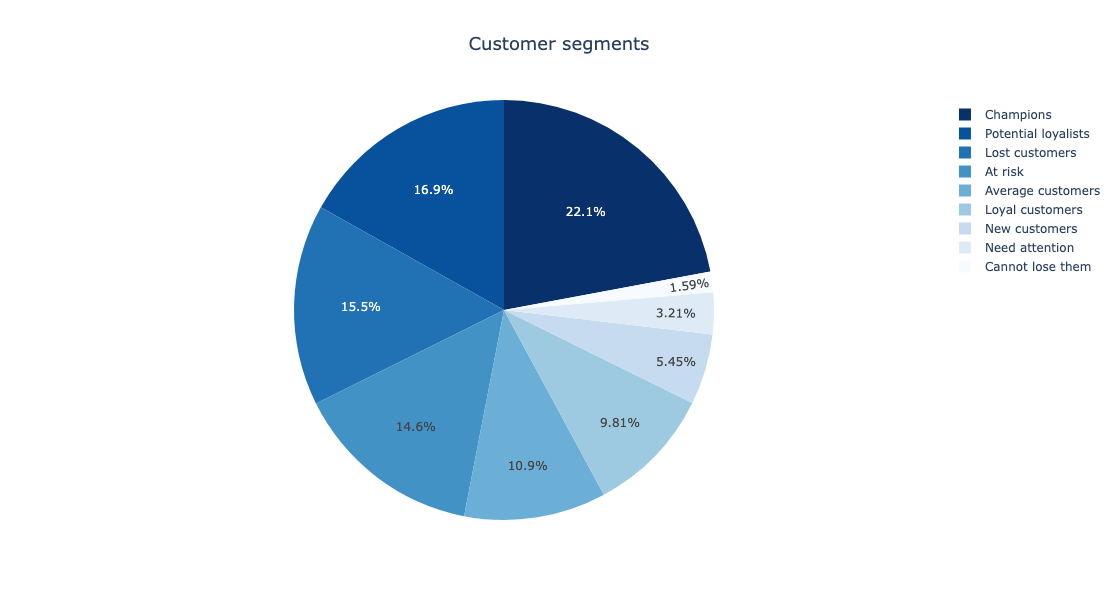

In [377]:
df_segments = rfm["Segment"].value_counts().reset_index(name="Count")

# creating pie chart
fig = px.pie(
    df_segments, 
    values="Count",
    names="Segment",
    color_discrete_sequence=px.colors.sequential.Blues[::-1],
    title="Customer segments"
)

# formating it
fig.update_layout(
    title_font=dict(size=18),
    title_x=0.5,
    width=600,
    height=600
)

fig.update_traces(textposition='inside', textinfo='percent')

fig.show()

In [382]:
segments_info = (
    rfm.merge(
        rfm_df[["CustomerID", "InvoiceNo"]],
        on="CustomerID",
        how="left"
    )
    .groupby("Segment")
    .agg(
        Clients=("CustomerID", "nunique"),
        Orders=("InvoiceNo", "nunique"),
        Revenue=("Monetary", "sum"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean")
    )
    .reset_index()
)

In [384]:
segments_info["Revenue"] = segments_info["Revenue"].map("£{:,.0f}".format)
segments_info["AvgMonetary"] = segments_info["AvgMonetary"].map("£{:,.0f}".format)
segments_info["AvgRecency"] = segments_info["AvgRecency"].round(1)
segments_info["AvgFrequency"] = segments_info["AvgFrequency"].round(1)

total_revenue = rfm["Monetary"].sum()
segments_info["RevenueShare"] = (
    rfm.groupby("Segment")["Monetary"].sum() / total_revenue
).values

segments_info["RevenueShare"] = segments_info["RevenueShare"].map("{:.1%}".format)

In [388]:
segment_order = [
    "Champions",
    "Loyal customers",
    "Potential loyalists",
    "New customers",
    "Cannot lose them",
    "At risk",
    "Lost customers",
    "Others"
]

segments_info["Segment"] = pd.Categorical(
    segments_info["Segment"],
    categories=segment_order,
    ordered=True
)

segments_info = segments_info.sort_values("Segment")

In [389]:
display(segments_info)

,Segment,Clients,Orders,TotalRevenue,AvgRecency,AvgFrequency,AvgMonetary,RevenueShare
3,Champions,956,10563,"£4,129,115,827",10.2,28.9,"£17,817",65.3%
5,Loyal customers,425,1463,"£83,820,857",64.5,3.6,"£2,076",10.6%
8,Potential loyalists,731,1235,"£13,488,225",35.6,1.9,£515,3.6%
7,New customers,236,263,"£1,630,969",18.5,1.1,£287,0.6%
2,Cannot lose them,69,512,"£23,614,769",153.5,8.8,"£3,077",2.7%
0,At risk,633,1328,"£16,653,130",180.3,2.3,£721,5.0%
4,Lost customers,671,680,"£2,411,143",225.9,1.0,£239,1.5%
1,NaN,474,1842,"£101,599,331",60.4,6.2,"£2,825",9.5%
6,NaN,139,516,"£7,356,417",33.0,3.7,£721,1.1%


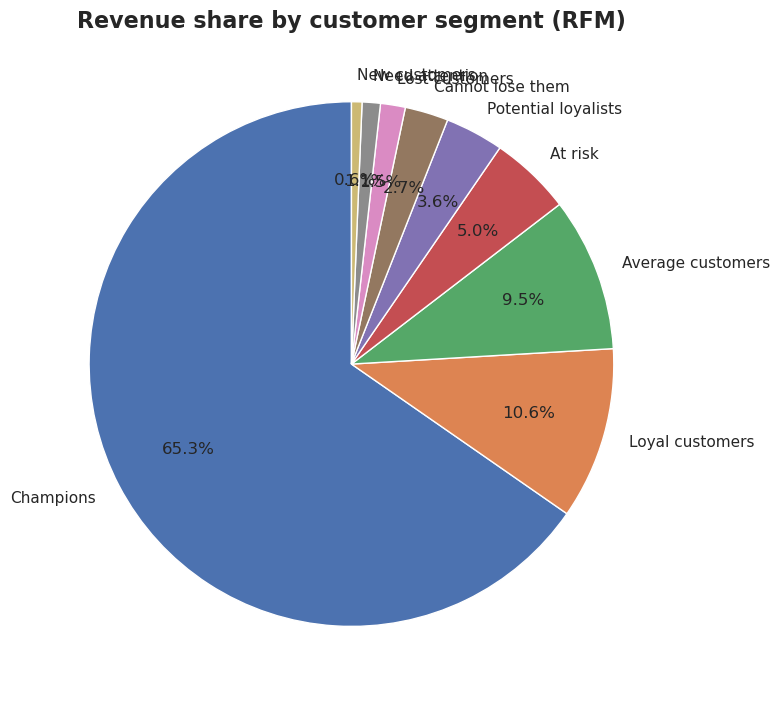

In [407]:
segment_revenue = (
    rfm.groupby("Segment")["Monetary"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 8))

plt.pie(
    segment_revenue,
    labels=segment_revenue.index,
    autopct="%1.1f%%",
    startangle=90,
    labeldistance=1.1,
    pctdistance=0.7,
    wedgeprops={"edgecolor": "white"}
)

plt.title("Revenue share by customer segment (RFM)", fontsize=16, weight="bold")

plt.tight_layout()
plt.show()

In [391]:
rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]].mean()

,Recency,Frequency,Monetary
Segment,,,
At risk,185.287520,2.097946,691.520066
Average customers,88.656118,3.886076,1746.985042
Cannot lose them,154.536232,7.420290,3384.985797
Champions,12.813808,11.049163,5970.773525
Lost customers,228.921013,1.013413,199.041490
Loyal customers,66.468235,3.442353,2178.435788
Need attention,34.755396,3.712230,706.055475
New customers,18.826271,1.114407,238.815381
Potential loyalists,38.882353,1.689466,430.347073


In [392]:
rfm[["Recency", "Frequency", "Monetary"]].corr()

,Recency,Frequency,Monetary
Recency,1.000000,-0.261232,-0.120905
Frequency,-0.261232,1.000000,0.547618
Monetary,-0.120905,0.547618,1.000000


## References
1. Carrie. *E-commerce Data*. https://www.kaggle.com/datasets/carrie1/ecommerce-data
2. Moreno, A. I. (2025, September 23). *Is This Really a Jupyter Notebook? — Customizing Jupyter Notebook Appearance with CSS*. Medium; Data Science Collective. https://medium.com/data-science-collective/this-is-really-a-jupyter-notebook-customizing-jupyter-notebook-appearance-with-css-b04d71ccd0a8
3. Wei, J. T., Lin, S. Y., & Wu, H. H. (2010). *A review of the application of RFM model*. African journal of business management, 4(19), 4199.
4. Palmatier, R. W., Petersen, J. A., & Germann, F. (2022). Marketing analytics : Based on first principles. Bloomsbury Publishing Plc.
5. Safa. (2024, July 6). *Building an RFM Analytics Dashboard using Python*. Medium. https://medium.com/@safadataanalyst/building-an-rfm-analytics-dashboard-using-python-52159826f742
6. *pandas.Timedelta — pandas 2.0.1 documentation*. (n.d.). Pandas.pydata.org. https://pandas.pydata.org/docs/reference/api/pandas.Timedelta.html
7. *matplotlib.pyplot.subplots — Matplotlib 3.6.0 documentation*. (n.d.). Matplotlib.org. https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
8. *pandas.DataFrame.agg — pandas 2.0.0 documentation*. (n.d.). Pandas.pydata.org. https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.agg.html
9. *pandas.qcut — pandas 2.1.3 documentation*. (n.d.). Pandas.pydata.org. https://pandas.pydata.org/docs/reference/api/pandas.qcut.html
10. *numpy.log1p — NumPy v2.3.dev0 Manual*. (2025). Numpy.org. https://numpy.org/devdocs/reference/generated/numpy.log1p.html
11. *Customer Segmentation using RFM Analysis*. (n.d.). Blog.rsquaredacademy.com. https://blog.rsquaredacademy.com/customer-segmentation-using-rfm-analysis/
12. Yadav, A. (2025, February). *How numpy.select() Works?*. Medium. https://medium.com/@amit25173/how-numpy-select-works-f11ed0de629b
13. *Pie Charts*. (n.d.). Plotly.com. https://plotly.com/python/pie-charts/
14. *Layout*. (n.d.). Plotly.com. https://plotly.com/python/reference/layout/
15. Khan, M. T. (2013). *Customers loyalty: Concept & definition (a review)*. International Journal of Information, Business and Management, 5(3), 168-191.